<a href="https://colab.research.google.com/github/DwilaksanaAbdullahRasyid/fft-transformer-scalper-btc/blob/main/FFT_TRANSFORMER_BTC_M5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##1 FFT-Transformer moving window


In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. AMBIL DATA & FEATURE ENGINEERING ---
def get_btc_data_advanced():
    print("Mengambil data BTC-USD 5 menit...")
    df = yf.download(tickers='BTC-USD', period='5d', interval='5m', progress=False)
    df = df.dropna()

    # Tambahkan Log Return untuk stasioneritas
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    return df.dropna()

# --- 2. FFT SMOOTHING (DENGAN DETRENDING) ---
def fft_smoothing(data, keep_fraction=0.15):
    n = len(data)
    x = np.arange(n)
    poly = np.polyfit(x, data, 1)
    trend = np.polyval(poly, x)
    detrended = data - trend

    fft_coeffs = np.fft.fft(detrended)
    limit = int(n * keep_fraction)
    fft_coeffs[limit : n - limit] = 0

    cleaned = np.real(np.fft.ifft(fft_coeffs))
    return cleaned + trend

# --- 3. ENHANCED TRANSFORMER ARCHITECTURE ---
class BTC_Transformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        # Tambahkan dropout untuk mencegah model memprediksi garis datar (overfitting ke mean)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

# --- 4. PREPARASI & TRAINING ---
# Parameter
window_size = 30
test_size = 50
epochs = 100 # Ditambah agar model sempat konvergen

df = get_btc_data_advanced()
smoothed_close = fft_smoothing(df['Close'].values.flatten(), keep_fraction=0.20)

# Gabungkan 3 Fitur: Smoothed Price, Volume, dan Log Return
features = np.column_stack((smoothed_close, df['Volume'].values, df['Log_Return'].values))
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# Membuat Dataset
X_list, y_list = [], []
for i in range(window_size, len(scaled_features) - test_size):
    X_list.append(scaled_features[i-window_size:i])
    y_list.append(scaled_features[i, 0]) # Target: Next Smoothed Price

X_train = torch.FloatTensor(np.array(X_list))
y_train = torch.FloatTensor(np.array(y_list)).view(-1, 1)

# Inisialisasi Model
model = BTC_Transformer(input_dim=3)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Learning rate lebih kecil untuk stabilitas

# Training Loop
print(f"Memulai Training ({epochs} Epochs)...")
model.train()
losses = []
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}")

# --- 5. TESTING (MOVING WINDOW) ---
model.eval()
preds, actuals = [], []

for i in range(len(scaled_features) - test_size, len(scaled_features)):
    window = scaled_features[i-window_size : i]
    input_tensor = torch.FloatTensor(window).unsqueeze(0)
    with torch.no_grad():
        out = model(input_tensor).item()
    preds.append(out)
    actuals.append(scaled_features[i, 0])

# --- 6. VISUALISASI ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
plt.plot(losses, color='blue')
plt.title("Loss Curve (Konvergensi Model)")
plt.yscale('log')

plt.subplot(2, 1, 2)
plt.plot(actuals, label='Actual Price (Smoothed)', marker='o', alpha=0.8)
plt.plot(preds, label='Transformer Prediction', linestyle='--', color='red', marker='x')
plt.title("Hasil Forecast: Responsif terhadap Perubahan (3 Fitur)")
plt.legend()

plt.tight_layout()
plt.show()

Mengambil data BTC-USD 5 menit...
Memulai Training (100 Epochs)...


KeyboardInterrupt: 

#2 FFT-Transformer Walk Forward

Mengambil data BTC-USD...
Melakukan Initial Training...
Memulai Walk-Forward Validation (100 steps)...

HASIL WALK-FORWARD VALIDATION
RMSE (Scaled)        : 0.131722
Directional Accuracy : 62.63%


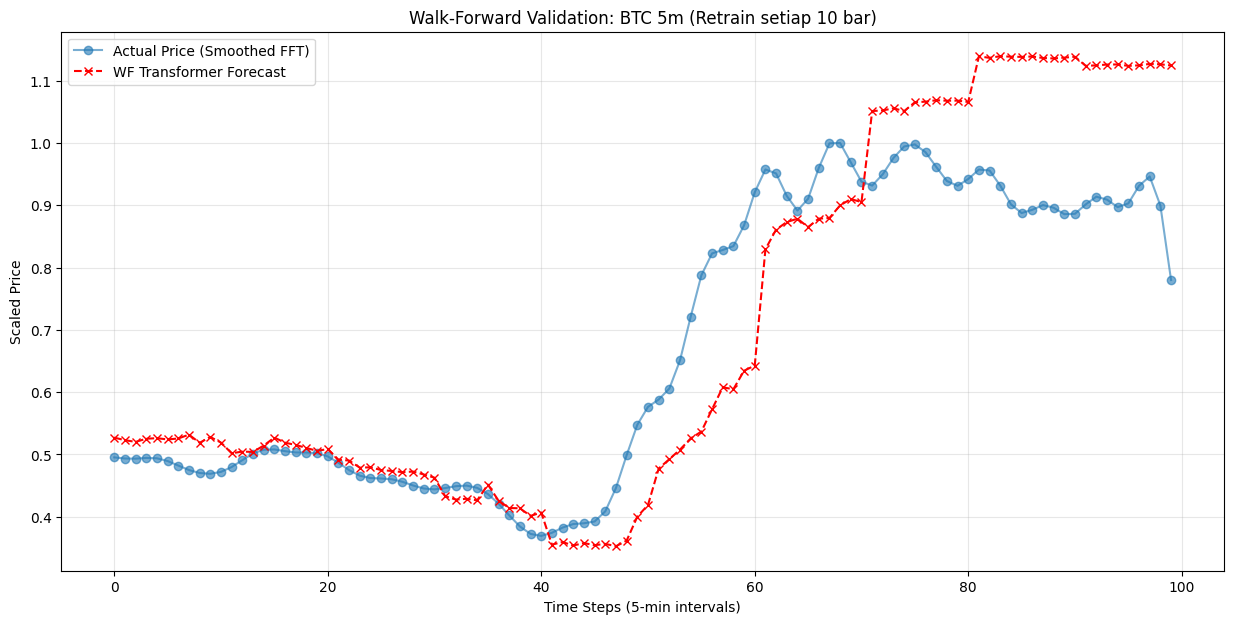

In [ ]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. DATA ACQUISITION & FEATURES ---
def get_btc_data():
    print("Mengambil data BTC-USD...")
    df = yf.download(tickers='BTC-USD', period='7d', interval='5m', progress=False)
    df = df.dropna()
    # Feature 1: Log Returns (Stasioner)
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    return df.dropna()

# --- 2. FFT SMOOTHING (DETRENDED) ---
def fft_smoothing(data, keep_fraction=0.20):
    n = len(data)
    x = np.arange(n)
    poly = np.polyfit(x, data, 1)
    trend = np.polyval(poly, x)
    detrended = data - trend

    fft_coeffs = np.fft.fft(detrended)
    limit = int(n * keep_fraction)
    fft_coeffs[limit : n - limit] = 0

    cleaned = np.real(np.fft.ifft(fft_coeffs))
    return cleaned + trend

# --- 3. TRANSFORMER ARCHITECTURE ---
class WalkForwardTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

# --- 4. PREPARASI DATA ---
window_size = 30
test_size = 100  # Kita tes pada 100 bar terakhir (~8 jam)
retrain_step = 10 # Model re-training setiap 10 bar baru

df = get_btc_data()
smoothed_close = fft_smoothing(df['Close'].values.flatten(), keep_fraction=0.20)
features = np.column_stack((smoothed_close, df['Volume'].values, df['Log_Return'].values))

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# --- 5. INITIAL TRAINING ---
# Data sebelum 'test_size' digunakan untuk training awal
train_data = scaled_features[:-test_size]

X_train, y_train = [], []
for i in range(window_size, len(train_data)):
    X_train.append(train_data[i-window_size:i])
    y_train.append(train_data[i, 0])

X_train = torch.FloatTensor(np.array(X_train))
y_train = torch.FloatTensor(np.array(y_train)).view(-1, 1)

model = WalkForwardTransformer(input_dim=3)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

print("Melakukan Initial Training...")
model.train()
for epoch in range(50):
    optimizer.zero_grad()
    loss = criterion(model(X_train), y_train)
    loss.backward()
    optimizer.step()

# --- 6. WALK-FORWARD VALIDATION LOOP ---
model.eval()
wf_preds = []
wf_actuals = []
history_X = list(X_train)
history_y = list(y_train)

print(f"Memulai Walk-Forward Validation ({test_size} steps)...")

for i in range(len(scaled_features) - test_size, len(scaled_features)):
    # 1. Predict
    current_window = scaled_features[i-window_size:i]
    input_tensor = torch.FloatTensor(current_window).unsqueeze(0)

    with torch.no_grad():
        pred = model(input_tensor).item()

    wf_preds.append(pred)
    wf_actuals.append(scaled_features[i, 0])

    # 2. Update History (Simulasi data baru masuk)
    history_X.append(torch.FloatTensor(current_window))
    history_y.append(torch.FloatTensor([scaled_features[i, 0]]))

    # 3. Incremental Re-training (Fine-tuning) setiap 10 bar
    if (i - (len(scaled_features) - test_size)) % retrain_step == 0 and i > (len(scaled_features) - test_size):
        model.train()
        # Ambil batch terbaru untuk fine-tuning cepat
        X_batch = torch.stack(history_X[-retrain_step:])
        y_batch = torch.stack(history_y[-retrain_step:]).view(-1, 1)

        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        model.eval()

# --- 7. EVALUASI AKHIR ---
rmse = np.sqrt(mean_squared_error(wf_actuals, wf_preds))
# Hitung akurasi arah (Up/Down)
dir_acc = np.mean((np.diff(wf_actuals) > 0) == (np.diff(wf_preds) > 0)) * 100

print("\n" + "="*30)
print("HASIL WALK-FORWARD VALIDATION")
print("="*30)
print(f"RMSE (Scaled)        : {rmse:.6f}")
print(f"Directional Accuracy : {dir_acc:.2f}%")
print("="*30)

# --- 8. VISUALISASI ---
plt.figure(figsize=(15, 7))
plt.plot(wf_actuals, label='Actual Price (Smoothed FFT)', marker='o', alpha=0.6)
plt.plot(wf_preds, label='WF Transformer Forecast', linestyle='--', color='red', marker='x')
plt.title(f"Walk-Forward Validation: BTC 5m (Retrain setiap {retrain_step} bar)")
plt.xlabel("Time Steps (5-min intervals)")
plt.ylabel("Scaled Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import torch

# Tentukan nama file
model_path = "btc_transformer_optimum.pth"

# Menyimpan bobot model (state_dict)
torch.save(model.state_dict(), model_path)

print(f"Bobot model optimum telah berhasil disimpan di: {model_path}")

# Tips: Untuk mendownload ke laptop Acer Nitro 5 Anda:
# from google.colab import files
# files.download(model_path)

Bobot model optimum telah berhasil disimpan di: btc_transformer_optimum.pth


#3 FFT-Transformer walk forward
###DENGAN SIGNAL BUY AND SELL

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

# --- 1. DATA & FEATURE ENGINEERING ---
def get_live_data():
    df = yf.download(tickers='BTC-USD', period='7d', interval='5m', progress=False)
    df = df.dropna()
    # Log Return untuk model
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    # Volatilitas Lokal untuk Dynamic SL/TP (Rolling Std Dev)
    df['Volatilitas'] = df['Log_Return'].rolling(window=10).std()
    return df.dropna()

def fft_smoothing(data, keep_fraction=0.15):
    n = len(data)
    x = np.arange(n)
    poly = np.polyfit(x, data, 1)
    trend = np.polyval(poly, x)
    detrended = data - trend
    fft_coeffs = np.fft.fft(detrended)
    limit = int(n * keep_fraction)
    fft_coeffs[limit : n - limit] = 0
    return np.real(np.fft.ifft(fft_coeffs)) + trend

# --- 2. TRANSFORMER MODEL ---
class TradingTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

# --- 3. SETUP PARAMETERS ---
modal_awal = 100.0
leverage = 10.0
margin_per_trade = 1.0  # 1 USDT
posisi_size = margin_per_trade * leverage # 10 USDT buying power
window_size = 30
test_size = 100

df = get_live_data()
# Training menggunakan FFT, tapi kita simpan data RAW untuk testing
smoothed_close = fft_smoothing(df['Close'].values.flatten(), keep_fraction=0.15)
features = np.column_stack((smoothed_close, df['Volume'].values, df['Log_Return'].values))

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# --- 4. INITIAL TRAINING ---
X_init, y_init = [], []
for i in range(window_size, len(scaled_features) - test_size):
    X_init.append(scaled_features[i-window_size:i])
    y_init.append(scaled_features[i, 0])

X_train = torch.FloatTensor(np.array(X_init))
y_train = torch.FloatTensor(np.array(y_init)).view(-1, 1)

model = TradingTransformer(input_dim=3)
optimizer = optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.MSELoss()

print("Memulai Training...")
model.train()
epoch_losses = []
for epoch in range(100):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())

# --- 5. WALK-FORWARD BACKTEST (REAL DATA EXECUTION) ---
model.eval()
equity = modal_awal
equity_history = [modal_awal]
trade_log = [] # Menyimpan info untuk visualisasi

print("Memulai Walk-Forward Backtest pada Data Asli...")
for i in range(len(df) - test_size, len(df) - 1):
    # Input ke model tetap hasil FFT (Smooth)
    window = scaled_features[i-window_size+1 : i+1]
    input_tensor = torch.FloatTensor(window).unsqueeze(0)

    with torch.no_grad():
        pred_scaled = model(input_tensor).item()

    current_scaled = scaled_features[i, 0]

    # Eksekusi pada harga ASLI (Raw)
    price_now = float(df['Close'].iloc[i])

    if pred_scaled > current_scaled: # Sinyal BUY
        # Dynamic SL/TP berdasarkan Volatilitas (Min 0.1%, Max 1%)
        vol = df['Volatilitas'].iloc[i]
        sl_dist = np.clip(vol, 0.001, 0.01)
        tp_dist = sl_dist * 3 # Risk Reward 1:3

        tp_price = price_now * (1 + tp_dist)
        sl_price = price_now * (1 - sl_dist)

        # Realitas bar berikutnya
        high_next = float(df['High'].iloc[i+1])
        low_next = float(df['Low'].iloc[i+1])
        close_next = float(df['Close'].iloc[i+1])

        if low_next <= sl_price:
            pnl = -posisi_size * sl_dist * leverage # Rugi x Leverage
            status = 'SL'
            exit_p = sl_price
        elif high_next >= tp_price:
            pnl = posisi_size * tp_dist * leverage # Untung x Leverage
            status = 'TP'
            exit_p = tp_price
        else:
            pnl = posisi_size * ((close_next - price_now) / price_now) * leverage
            status = 'EXIT'
            exit_p = close_next

        equity += pnl
        trade_log.append({'idx': i, 'type': 'BUY', 'entry': price_now, 'exit': exit_p, 'status': status})

    equity_history.append(equity)

# --- 6. VISUALISASI ---
plt.figure(figsize=(16, 12))

# A. Loss tiap Epoch
plt.subplot(3, 1, 1)
plt.plot(epoch_losses, color='orange')
plt.title("Training Loss per Epoch")
plt.yscale('log')

# B. Equity Growth
plt.subplot(3, 1, 2)
plt.plot(equity_history, color='green', label='Equity Curve')
plt.axhline(y=100, color='red', linestyle='--')
plt.title(f"Equity Growth (Final: {equity:.2f} USDT)")
plt.legend()

# C. Buy/Sell Signal pada Data Asli
plt.subplot(3, 1, 3)
test_prices = df['Close'].iloc[-test_size:].values
plt.plot(test_prices, label='BTC Price (Raw)', color='blue', alpha=0.5)

for t in trade_log:
    # Offset index untuk subplot (0 sampai test_size)
    rel_idx = t['idx'] - (len(df) - test_size)
    if t['status'] == 'TP':
        plt.scatter(rel_idx, t['entry'], marker='^', color='lime', s=100)
    elif t['status'] == 'SL':
        plt.scatter(rel_idx, t['entry'], marker='v', color='red', s=100)
    else:
        plt.scatter(rel_idx, t['entry'], marker='o', color='gray', s=50)

plt.title("Keputusan Trading pada Observasi (Segitiga = Entry)")
plt.tight_layout()
plt.show()

print(f"Total Profit/Loss: {equity - 100:.4f} USDT")

/tmp/ipykernel_816/2123451735.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers='BTC-USD', period='7d', interval='5m', progress=False)


KeyboardInterrupt: 

In [ ]:
# Simpan bobot ke file lokal di Google Colab
torch.save(model.state_dict(), "transformer_walkforward_btc_weights.pth")
print("Bobot model berhasil disimpan! Anda sekarang bisa menjalankan ulang tanpa training.")

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# --- 1. SETUP MODEL (Arsitektur Harus Sama) ---
class TradingTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8, num_layers=3):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

# --- 2. LOAD WEIGHTS (TANPA TRAINING) ---
model_eval = TradingTransformer(input_dim=3)
weight_path = "transformer_walkforward_btc_weights.pth"

try:
    model_eval.load_state_dict(torch.load(weight_path))
    model_eval.eval()
    print(f"✅ Bobot '{weight_path}' Berhasil Dimuat. Siap Testing.")
except FileNotFoundError:
    print(f"❌ Error: File '{weight_path}' tidak ditemukan. Pastikan file ada di folder Colab.")

# --- 3. PARAMETER TRADING ---
modal_awal = 100.0
leverage = 20
margin_per_trade = 2.0
posisi_size = margin_per_trade * leverage
sl_statis_pct = 0.001  # 0.1%
tp_statis_pct = 0.0015 # 0.15% (RR 1:1.5)
window_size = 30
test_size = 100

# --- 4. PREPARASI DATA ---
df = yf.download(tickers='BTC-USD', period='7d', interval='5m', progress=False).dropna()
df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

def fft_smoothing(data, keep_fraction=0.15):
    n = len(data)
    x = np.arange(n)
    poly = np.polyfit(x, data, 1)
    trend = np.polyval(poly, x)
    detrended = data - trend
    fft_coeffs = np.fft.fft(detrended)
    fft_coeffs[int(n*keep_fraction) : n-int(n*keep_fraction)] = 0
    return np.real(np.fft.ifft(fft_coeffs)) + trend

smoothed_close = fft_smoothing(df['Close'].values.flatten())
# Menyesuaikan panjang Log_Return agar pas dengan kolom lainnya
log_ret_col = df['Log_Return'].fillna(0).values
features = np.column_stack((smoothed_close, df['Volume'].values, log_ret_col))

scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)

# --- 5. SIMULASI TRADING (BACKTEST DUA ARAH) ---
equity = modal_awal
equity_history = [modal_awal]
trade_log = []
# Ringkasan hasil yang lebih detail untuk PhD Analysis
trade_results = {'Long_TP': 0, 'Long_SL': 0, 'Short_TP': 0, 'Short_SL': 0, 'EXIT': 0}

for i in range(len(scaled_features) - test_size, len(scaled_features) - 1):
    window = scaled_features[i-window_size+1 : i+1]
    input_tensor = torch.FloatTensor(window).unsqueeze(0)

    with torch.no_grad():
        pred_scaled = model_eval(input_tensor).item()

    current_scaled = scaled_features[i, 0]
    price_now = float(df['Close'].iloc[i])

    # Realitas di data RAW bar berikutnya
    high_next = float(df['High'].iloc[i+1])
    low_next = float(df['Low'].iloc[i+1])
    close_next = float(df['Close'].iloc[i+1])

    pnl = 0
    t_type = None # LONG or SHORT
    status = 'EXIT'
    exit_p = close_next

    # LOGIKA DECISION DIRECTION
    if pred_scaled > current_scaled:
        # --- LONG POSITION ---
        t_type = 'LONG'
        tp_price = price_now * (1 + tp_statis_pct)
        sl_price = price_now * (1 - sl_statis_pct)

        if low_next <= sl_price:
            pnl = -posisi_size * sl_statis_pct * leverage
            status, exit_p = 'SL', sl_price
            trade_results['Long_SL'] += 1
        elif high_next >= tp_price:
            pnl = posisi_size * tp_statis_pct * leverage
            status, exit_p = 'TP', tp_price
            trade_results['Long_TP'] += 1
        else:
            pnl = posisi_size * ((close_next - price_now) / price_now) * leverage
            trade_results['EXIT'] += 1

    elif pred_scaled < current_scaled:
        # --- SHORT POSITION ---
        t_type = 'SHORT'
        tp_price = price_now * (1 - tp_statis_pct)
        sl_price = price_now * (1 + sl_statis_pct)

        if high_next >= sl_price:
            pnl = -posisi_size * sl_statis_pct * leverage
            status, exit_p = 'SL', sl_price
            trade_results['Short_SL'] += 1
        elif low_next <= tp_price:
            pnl = posisi_size * tp_statis_pct * leverage
            status, exit_p = 'TP', tp_price
            trade_results['Short_TP'] += 1
        else:
            pnl = posisi_size * ((price_now - close_next) / price_now) * leverage
            trade_results['EXIT'] += 1

    if t_type:
        equity += pnl
        trade_log.append({
            'idx': i,
            'type': t_type,
            'entry': price_now,
            'exit': exit_p,
            'status': status
        })

    equity_history.append(equity)

# --- 6. VISUALISASI ---
plt.figure(figsize=(16, 12))

# Subplot 1: Equity Growth
plt.subplot(2, 1, 1)
plt.plot(equity_history, color='darkgreen', linewidth=2, label='Equity Curve')
plt.axhline(y=100, color='red', linestyle='--', alpha=0.5)
plt.fill_between(range(len(equity_history)), 100, equity_history, color='green', alpha=0.1)
plt.title(f"Final Equity: {equity:.4f} USDT (Bi-Directional | Leverage 10x)")
plt.ylabel("USDT")
plt.legend()

# Subplot 2: Audit Trading (Long vs Short)
plt.subplot(2, 1, 2)
test_prices = df['Close'].iloc[-test_size:].values
plt.plot(test_prices, label='BTC Price (Raw)', color='blue', alpha=0.2)



color_map = {'TP': 'lime', 'SL': 'red', 'EXIT': 'gray'}
for t in trade_log:
    rel_idx = t['idx'] - (len(df) - test_size)
    if 0 <= rel_idx < test_size - 1:
        c = color_map.get(t['status'], 'gray')
        # Segitiga Atas untuk LONG, Segitiga Bawah untuk SHORT
        m = '^' if t['type'] == 'LONG' else 'v'
        # Warna marker entry dibedakan: Biru untuk Long, Oranye untuk Short
        m_color = 'blue' if t['type'] == 'LONG' else 'orange'

        plt.scatter(rel_idx, t['entry'], marker=m, color=m_color, s=100, label=t['type'] if rel_idx == trade_log[0]['idx']-(len(df)-test_size) else "")
        plt.scatter(rel_idx + 1, t['exit'], marker='o', color=c, s=60, edgecolors='black')
        plt.plot([rel_idx, rel_idx + 1], [t['entry'], t['exit']], color=c, alpha=0.6)

plt.title("Audit Trading: Long (^) vs Short (v) | TP (Hijau), SL (Merah), Exit (Abu)")
plt.xlabel("Observations (Time Steps)")
plt.ylabel("Price (USD)")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Ringkasan Trade: {trade_results}")
print(f"Net Profit/Loss: {equity - 100:.4f} USDT")

#4 FFT-Transformer walk forward 500 Epoch
##DENGAN SIGNAL BUY AND SELL

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim

# --- CHECK DEVICE ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan perangkat: {device}")

# --- 1. DATA & FEATURE ENGINEERING ---
def get_live_data():
    # Mengambil data 14 hari untuk basis statistik yang lebih kuat
    df = yf.download(tickers='BTC-USD', period='14d', interval='5m', progress=False)
    df = df.dropna()
    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))
    return df.dropna()

def fft_smoothing(data, keep_fraction=0.15):
    n = len(data)
    fft_coeffs = np.fft.fft(data)
    limit = int(n * keep_fraction)
    fft_coeffs[limit : n - limit] = 0
    return np.real(np.fft.ifft(fft_coeffs))

Menggunakan perangkat: cpu


In [ ]:
# --- 2. TRANSFORMER MODEL (DENGAN REGULARISASI LEBIH KUAT) ---
class TradingTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        # REKOMENDASI: Dropout dinaikkan ke 0.3 untuk meredam jitter/overfitting
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.3)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

# --- 3. SETUP PARAMETERS & DATA PREPARATION ---
modal_awal = 100.0
leverage = 20
margin_per_trade = 2
posisi_size = margin_per_trade * leverage
window_size = 30
test_size = 120
threshold = 0.0006
sl_statis_pct = 0.003
tp_statis_pct = 0.0045

df = get_live_data()

# A. Buat data Smooth FFT untuk INPUT (X)
# Pastikan data Close berbentuk 1D menggunakan .values.flatten()
raw_close_1d = df['Close'].values.flatten()

smoothed_close = fft_smoothing(raw_close_1d, keep_fraction=0.15)
features_input = np.column_stack((smoothed_close, df['Volume'].values, df['Log_Return'].values))

# B. REKOMENDASI: Buat target RAW yang dihaluskan (Label Smoothing) untuk TARGET (Y)
# Gunakan raw_close_1d yang sudah dipastikan 1 dimensi
target_smoothed = pd.Series(raw_close_1d).rolling(window=3, min_periods=1).mean().values
features_target = np.column_stack((target_smoothed, df['Volume'].values, df['Log_Return'].values))

# Lanjutkan dengan scaling
scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()

scaled_in = scaler_in.fit_transform(features_input)
scaled_out = scaler_out.fit_transform(features_target)

# --- 4. INITIAL TRAINING ON GPU ---
X_init, y_init = [], []
for i in range(window_size, len(scaled_in) - test_size):
    X_init.append(scaled_in[i-window_size:i])
    y_init.append(scaled_out[i, 0])

X_train = torch.FloatTensor(np.array(X_init)).to(device)
y_train = torch.FloatTensor(np.array(y_init)).view(-1, 1).to(device)

model = TradingTransformer(input_dim=3).to(device)
# REKOMENDASI: weight_decay (L2 Regularization) ditambahkan untuk stabilitas bobot
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)
criterion = nn.MSELoss()

print(f"Memulai Training Hybrid (Smooth-to-Raw Filtered) di {device}...")
model.train()
epoch_losses = []
for epoch in range(500):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    loss.backward()
    optimizer.step()
    epoch_losses.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/500 - Loss: {loss.item():.6f}")



/tmp/ipykernel_696/830241763.py:17: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers='BTC-USD', period='14d', interval='5m', progress=False)


Memulai Training Hybrid (Smooth-to-Raw Filtered) di cpu...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Simpan ke folder spesifik di Drive Bapak
path_drive = "/content/drive/MyDrive/transformer_WF_btc_500epoch.pth"
torch.save(model.state_dict(), path_drive)

print(f"Bobot model tersimpan permanen di Google Drive: {path_drive}")

In [ ]:
# --- 5. WALK-FORWARD BACKTEST DENGAN DYNAMIC BIAS CORRECTION ---
model.eval()
equity = modal_awal
equity_history = [modal_awal]
trade_log = []
preds_tracking = []
actuals_tracking = []
errors = [] # List untuk menyimpan historical errors (pred_raw - actual)
trade_results = {'Long_TP': 0, 'Long_SL': 0, 'Short_TP': 0, 'Short_SL': 0, 'EXIT': 0}

print("Memulai Walk-Forward Backtest dengan Bias Correction...")

for i in range(len(df) - test_size, len(df) - 1):
    # Prepare input window (Smoothed)
    window = scaled_in[i-window_size+1 : i+1]
    input_tensor = torch.FloatTensor(window).unsqueeze(0).to(device)

    with torch.no_grad():
        # 1. Prediksi Mentah dari Model (yang mungkin 'melayang')
        raw_pred_scaled = model(input_tensor).item()

    # 2. Ambil Aktual Scaled saat ini (Raw)
    raw_actual_scaled = scaler_out.transform(features_target[i].reshape(1, -1))[0, 0]

    # 3. HITUNG BIAS CORRECTION (Rolling Mean of Errors)
    # Kita hitung bias dari 5 observasi terakhir untuk koreksi posisi
    current_bias = 0
    if len(errors) > 0:
        # Menggunakan rata-rata error terakhir untuk menggeser prediksi
        current_bias = np.mean(errors[-5:])

    # 4. Koreksi Prediksi: Menarik prediksi mentah kembali ke level aktual
    corrected_pred_scaled = raw_pred_scaled - current_bias

    # Simpan error mentah untuk perhitungan bias berikutnya
    errors.append(raw_pred_scaled - raw_actual_scaled)

    # Tracking untuk visualisasi menggunakan nilai yang sudah dikoreksi
    preds_tracking.append(corrected_pred_scaled)
    actuals_tracking.append(raw_actual_scaled)

    # --- LOGIKA TRADING ---
    price_now = float(df['Close'].iloc[i])
    # Selisih kini dihitung berdasarkan hasil koreksi bias
    diff = (corrected_pred_scaled - raw_actual_scaled)

    h_next, l_next, c_next = float(df['High'].iloc[i+1]), float(df['Low'].iloc[i+1]), float(df['Close'].iloc[i+1])

    t_type = None
    pnl = 0
    status = 'EXIT'
    exit_p = c_next

    if diff > threshold:
        t_type = 'LONG'
        tp_p, sl_p = price_now * (1 + tp_statis_pct), price_now * (1 - sl_statis_pct)
        if l_next <= sl_p:
            pnl, status, exit_p = -posisi_size * sl_statis_pct * leverage, 'SL', sl_p
            trade_results['Long_SL'] += 1
        elif h_next >= tp_p:
            pnl, status, exit_p = posisi_size * tp_statis_pct * leverage, 'TP', tp_p
            trade_results['Long_TP'] += 1
        else:
            pnl = posisi_size * ((c_next - price_now) / price_now) * leverage
            trade_results['EXIT'] += 1

    elif diff < -threshold:
        t_type = 'SHORT'
        tp_p, sl_p = price_now * (1 - tp_statis_pct), price_now * (1 + sl_statis_pct)
        if h_next >= sl_p:
            pnl, status, exit_p = -posisi_size * sl_statis_pct * leverage, 'SL', sl_p
            trade_results['Short_SL'] += 1
        elif l_next <= tp_p:
            pnl, status, exit_p = posisi_size * tp_statis_pct * leverage, 'TP', tp_p
            trade_results['Short_TP'] += 1
        else:
            pnl = posisi_size * ((price_now - c_next) / price_now) * leverage
            trade_results['EXIT'] += 1

    if t_type:
        equity += pnl
        trade_log.append({'idx': i, 'type': t_type, 'entry': price_now, 'exit': exit_p, 'status': status})

    equity_history.append(equity)

In [ ]:
# --- 6. VISUALISASI INTEGRASI (3 SUBPLOTS) ---
plt.figure(figsize=(16, 18)) # Ukuran diperpanjang agar 3 plot tidak berhimpitan

# --- SUBPLOT 1: AKURASI PREDIKSI (SCALED SPACE) ---
plt.subplot(3, 1, 1)
plt.plot(actuals_tracking, label='Actual RAW (Scaled)', color='blue', alpha=0.6)
plt.plot(preds_tracking, label='Transformer Prediction', color='red', linestyle='--', alpha=0.8)
plt.title("Audit Prediksi: Hybrid Smooth-to-Raw (Scaled Space)")
plt.ylabel("Value (MinMaxScaler)")
plt.legend()
plt.grid(True, alpha=0.2)

# --- SUBPLOT 2: EQUITY CURVE (PORTFOLIO PERFORMANCE) ---
plt.subplot(3, 1, 2)
plt.plot(equity_history, color='green', linewidth=2, label='Equity Growth')
plt.fill_between(range(len(equity_history)), 100, equity_history, color='green', alpha=0.1)
plt.axhline(y=100, color='red', linestyle='--', alpha=0.5)
plt.title(f"Equity Curve - Final Balance: {equity:.2f} USDT")
plt.ylabel("USDT")
plt.legend()
plt.grid(True, alpha=0.2)

# --- SUBPLOT 3: AUDIT TRADING DETAIL (PRICE ACTION SPACE) ---
plt.subplot(3, 1, 3)
test_prices = df['Close'].iloc[-test_size:].values
plt.plot(test_prices, label='BTC Price (Raw)', color='black', alpha=0.2)

color_map = {'TP': 'lime', 'SL': 'red', 'EXIT': 'gray'}
# Tambahkan set untuk handle legend label agar tidak duplikat
labels_added = []

for t in trade_log:
    rel_idx = t['idx'] - (len(df) - test_size)
    if 0 <= rel_idx < test_size - 1:
        c = color_map.get(t['status'], 'gray')
        m = '^' if t['type'] == 'LONG' else 'v'
        m_color = 'blue' if t['type'] == 'LONG' else 'orange'

        # Logika label legend agar rapi
        current_label = t['type']
        if current_label not in labels_added:
            plt.scatter(rel_idx, t['entry'], marker=m, color=m_color, s=120, label=current_label, zorder=5)
            labels_added.append(current_label)
        else:
            plt.scatter(rel_idx, t['entry'], marker=m, color=m_color, s=120, zorder=5)

        plt.scatter(rel_idx + 1, t['exit'], marker='o', color=c, s=60, edgecolors='black', zorder=5)
        plt.plot([rel_idx, rel_idx + 1], [t['entry'], t['exit']], color=c, alpha=0.7, linewidth=2)

plt.title("Audit Trading: Long (^) vs Short (v) | Titik: Hijau(TP), Merah(SL), Abu(Exit)")
plt.xlabel("Observations (Time Steps)")
plt.ylabel("Price (USD)")
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)

# --- FINALIZE ---
plt.tight_layout()
plt.show()

print("\n" + "="*40)
print(f"Ringkasan Trade: {trade_results}")
print(f"Net Profit/Loss: {equity - 100:.4f} USDT")
print("="*40)

In [ ]:
# --- 5.1 GENERATE TRADE TABLE (COMPOUNDING + MARKET FEES AUDIT) ---
table_data = []
current_equity = modal_awal
risk_ratio = margin_per_trade / modal_awal
taker_fee_rate = 0.00055  # 0.055% per eksekusi (Bybit Taker Fee)

for t in trade_log:
    # 1. POSISI SIZE DINAMIS (COMPOUNDING)
    current_margin = current_equity * risk_ratio
    current_posisi_size = current_margin * leverage

    # 2. HITUNG BIAYA TRANSAKSI (FEE)
    # Fee dihitung dari Total Nilai Posisi (Margin x Leverage)
    fee_open = current_posisi_size * taker_fee_rate

    # 3. Persentase Pergerakan Harga Murni
    pnl_pct_no_lev = 0
    if t['status'] == 'TP':
        pnl_pct_no_lev = tp_statis_pct * 100
    elif t['status'] == 'SL':
        pnl_pct_no_lev = -sl_statis_pct * 100
    else: # EXIT
        if t['type'] == 'LONG':
            pnl_pct_no_lev = ((t['exit'] - t['entry']) / t['entry']) * 100
        else: # SHORT
            pnl_pct_no_lev = ((t['entry'] - t['exit']) / t['entry']) * 100

    # 4. PnL KOTOR (Gross PnL)
    gross_pnl_usdt = (pnl_pct_no_lev / 100) * current_posisi_size

    # 5. BIAYA EXIT (Fee saat menutup posisi)
    # Nilai posisi saat exit mungkin sedikit berbeda, tapi untuk simulasi kita gunakan posisi awal
    fee_close = current_posisi_size * taker_fee_rate
    total_fee = fee_open + fee_close

    # 6. PnL BERSIH (Net PnL)
    net_pnl_usdt = gross_pnl_usdt - total_fee

    # UPDATE EKUITAS REALISTIS
    current_equity += net_pnl_usdt

    table_data.append({
        'Step': t['idx'],
        'Type': t['type'],
        'Entry Price': round(t['entry'], 2),
        'Exit Price': round(t['exit'], 2),
        'Status': t['status'],
        'PnL % (Gross)': f"{pnl_pct_no_lev:+.2f}%",
        'Trading Fee (USDT)': f"{total_fee:.4f}",
        'Net PnL (USDT)': f"{net_pnl_usdt:+.4f}",
        'Cumulative Equity': round(current_equity, 2)
    })

# Membuat DataFrame
df_trades_with_fees = pd.DataFrame(table_data)

# Visualisasi di Colab
from google.colab import data_table
data_table.enable_dataframe_formatter()
display(df_trades_with_fees)

print(f"\nFinal Balance (After Fees): {current_equity:.2f} USDT")

# --- 5.2 PERHITUNGAN WIN RATE & STATISTIK ---
total_trades = len(df_trades)
wins = len(df_trades[df_trades['PnL USDT (Real)'].astype(float) > 0])
losses = total_trades - wins
win_rate = (wins / total_trades) * 100 if total_trades > 0 else 0

# Menghitung Profit Factor (Total Win / Total Loss)
total_gross_profit = df_trades[df_trades['PnL USDT (Real)'].astype(float) > 0]['PnL USDT (Real)'].astype(float).sum()
total_gross_loss = abs(df_trades[df_trades['PnL USDT (Real)'].astype(float) < 0]['PnL USDT (Real)'].astype(float).sum())
profit_factor = total_gross_profit / total_gross_loss if total_gross_loss > 0 else float('inf')

print(f"\n" + "="*40)
print(f"STATISTIK PERFORMANCE")
print(f"="*40)
print(f"Total Trades : {total_trades}")
print(f"Win Rate     : {win_rate:.2f}%")
print(f"Total Wins   : {wins}")
print(f"Total Losses : {losses}")
print(f"Profit Factor: {profit_factor:.2f}")
print(f"="*40)

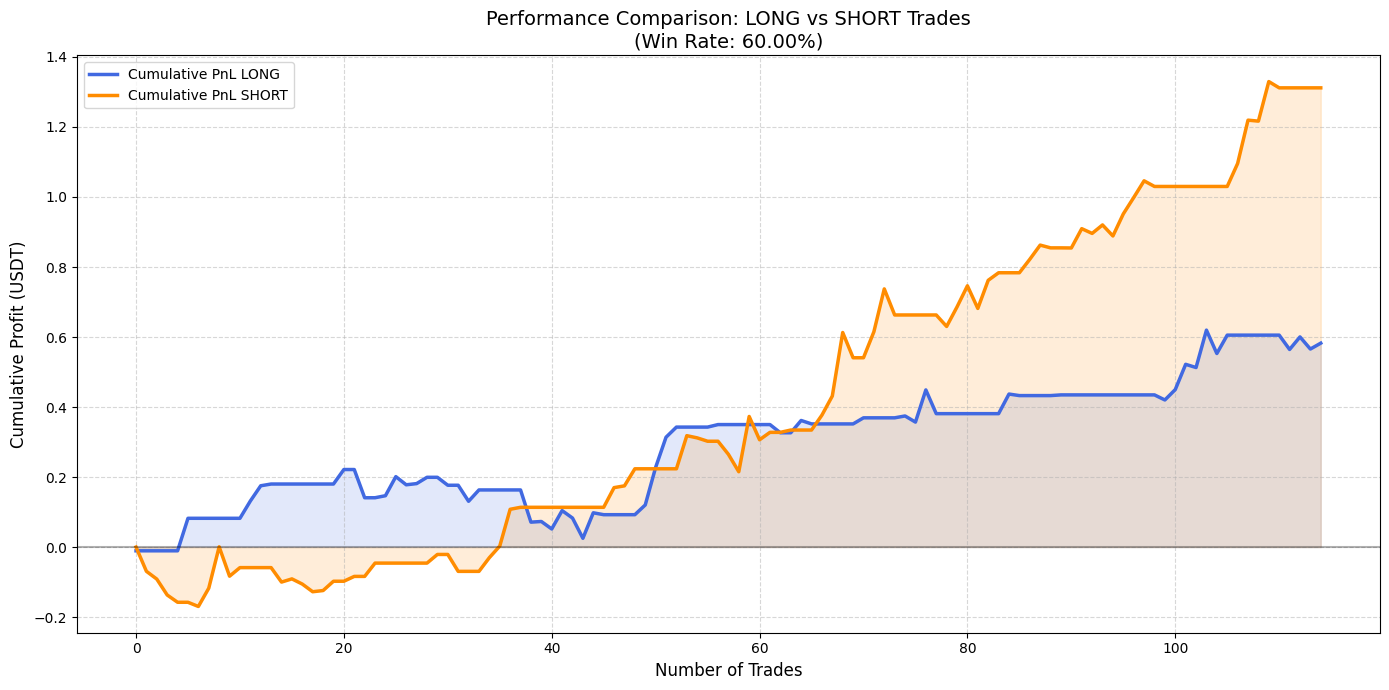

In [ ]:
# --- 6.1 GRAFIK PERBANDINGAN PNL LONG VS SHORT ---
plt.figure(figsize=(14, 7))

# Menghitung Cumulative PnL untuk masing-masing tipe (Compounded)
# Kita konversi PnL USDT (Real) kembali ke float untuk kalkulasi
df_trades['PnL_Float'] = df_trades['PnL USDT (Real)'].astype(float)

# Menggunakan np.where untuk memisahkan PnL per tipe, lalu cumsum
cum_pnl_long = df_trades['PnL_Float'].where(df_trades['Type'] == 'LONG', 0).cumsum()
cum_pnl_short = df_trades['PnL_Float'].where(df_trades['Type'] == 'SHORT', 0).cumsum()

plt.plot(cum_pnl_long, label='Cumulative PnL LONG', color='royalblue', linewidth=2.5)
plt.plot(cum_pnl_short, label='Cumulative PnL SHORT', color='darkorange', linewidth=2.5)

# Area fill untuk estetika
plt.fill_between(range(len(cum_pnl_long)), cum_pnl_long, color='royalblue', alpha=0.15)
plt.fill_between(range(len(cum_pnl_short)), cum_pnl_short, color='darkorange', alpha=0.15)

# Garis nol sebagai referensi
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.title(f"Performance Comparison: LONG vs SHORT Trades\n(Win Rate: {win_rate:.2f}%)", fontsize=14)
plt.xlabel("Number of Trades", fontsize=12)
plt.ylabel("Cumulative Profit (USDT)", fontsize=12)
plt.legend(loc='upper left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# DARI BOBOT TRAINING SEBELUMNYA

In [1]:
import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from google.colab import drive

# ==========================================
# 1. DEFINISI ARSITEKTUR MODEL
# ==========================================
class TradingTransformer(nn.Module):
    def __init__(self, input_dim=3, d_model=128, nhead=8):
        super().__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True, dropout=0.3)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.decoder = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer(x)
        return self.decoder(x[:, -1, :])

path_drive = "/content/drive/MyDrive/transformer_WF_btc_500epoch.pth"

In [2]:
# ==========================================
# 2. SETUP PARAMETER GLOBAL
# ==========================================
modal_awal = 100.0
leverage = 50
margin_per_trade = 10
posisi_size_fixed = margin_per_trade * leverage
rr_ratio = 2
window_size = 80
threshold = 0.00009
taker_fee_rate = 0.00055
round_trip_fee_pct = taker_fee_rate * 2
max_sl_pct = 0.005 # DISIPLIN: Maksimal Loss 0.5% per trade
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================
# 3. DOWNLOAD & PREPARASI DATA (ULTRA-ROBUST SYNC)
# ==========================================
print("📥 Mengunduh data BTC-USD (5m & 1m)...")
# Gunakan period 10 hari saja agar koneksi lebih stabil
df_5m_raw = yf.download(tickers='BTC-USD', period='8d', interval='5m', progress=False)
df_1m_raw = yf.download(tickers='BTC-USD', period='8d', interval='1m', progress=False)

def get_er_stable(df_raw, period=20): # Diubah dari 5 ke 20
    df = df_raw.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.index = pd.to_datetime(df.index).tz_localize(None)

    # Efficiency = Perpindahan bersih 20 menit / Total jarak tempuh 20 menit
    change = abs(df['Close'] - df['Close'].shift(period))
    volatility = abs(df['Close'] - df['Close'].shift(1)).rolling(window=period).sum()

    df['ER_1m'] = change / volatility
    return df[['ER_1m']].dropna()

def apply_fft(series, keep_fraction=0.15):
    raw_vals = series.values.flatten()
    n = len(raw_vals)
    fft_coeffs = np.fft.fft(raw_vals)
    fft_coeffs[int(n*keep_fraction) : n-int(n*keep_fraction)] = 0
    return np.real(np.fft.ifft(fft_coeffs))

# 1. Olah ER 1m
er_1m = get_er_stable(df_1m_raw)

# 2. Olah Data 5m
df_5m = df_5m_raw.copy()
if isinstance(df_5m.columns, pd.MultiIndex): df_5m.columns = df_5m.columns.get_level_values(0)
df_5m.index = pd.to_datetime(df_5m.index).tz_localize(None)

# 3. Sinkronisasi (Merge Asof)
df_final = pd.merge_asof(df_5m.sort_index(), er_1m.sort_index(),
                         left_index=True, right_index=True, direction='backward')

# 4. Hitung Indikator Setelah Sinkron
df_final['Log_Return'] = np.log(df_final['Close'] / df_final['Close'].shift(1))
df_final['Smoothed_Close'] = apply_fft(df_final['Close'])

# 5. Dropna & Slice Strict 1200
df_final.dropna(subset=['ER_1m', 'Log_Return', 'Smoothed_Close'], inplace=True)

if len(df_final) >= 1200:
    df_sim = df_final.iloc[-1200:].copy().reset_index(drop=True)
else:
    print(f"⚠️ Data terbatas, hanya ada {len(df_final)} baris.")
    df_sim = df_final.copy().reset_index(drop=True)

# ==========================================
# 4. LOAD MODEL & SCALING (FIXED: LOADING WEIGHTS)
# ==========================================

# 1. Pastikan Drive Terkoneksi
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Inisialisasi Arsitektur
model_loaded = TradingTransformer(input_dim=3, d_model=128, nhead=8).to(device)

# 3. PROSES PEMANGGILAN BOBOT (Ini yang tadi hilang)
if os.path.exists(path_drive):
    # Memuat file .pth ke dalam model
    model_loaded.load_state_dict(torch.load(path_drive, map_location=device))
    model_loaded.eval() # Mode evaluasi (Penting!)
    print(f"✅ Bobot model BERHASIL dimuat dari: {path_drive}")
else:
    print(f"❌ ERROR: File bobot tidak ditemukan di {path_drive}")
    # Berhenti jika bobot tidak ada agar tidak menggunakan bobot acak
    raise FileNotFoundError("Pastikan file .pth sudah ada di folder Drive Bapak.")

# 4. Inisialisasi Scaler
scaler_in = MinMaxScaler()
scaler_out = MinMaxScaler()

if not df_sim.empty:
    features_in = df_sim[['Smoothed_Close', 'Volume', 'Log_Return']].values
    features_out = df_sim[['Close']].values

    scaled_in = scaler_in.fit_transform(features_in)
    scaled_out = scaler_out.fit_transform(features_out)
    print(f"✅ SINKRONISASI & SCALING BERHASIL! {len(df_sim)} baris siap.")

# ==========================================
# 5. LOOP BACKTEST (SCALPING: AI + MOMENTUM + IBS ALIGNMENT)
# ==========================================
compounding_equity = modal_awal
equity_history = [modal_awal]
trade_log, errors_live = [], []
actuals_tracking, preds_tracking, slope_tracking = [], [], []

in_position = False
current_trade = None
er_threshold_agresif = 0.6
look_ahead_steps = 10

print(f"🚀 Memulai Simulasi Scalping (IBS & Momentum Aligned)...")

for i in range(window_size, len(df_sim) - look_ahead_steps):
    # --- A. GENERATE MULTI-STEP PREDICTION (T+10) ---
    temp_window = scaled_in[i-window_size : i].copy()
    future_preds = []
    with torch.no_grad():
        for _ in range(look_ahead_steps):
            input_tensor = torch.FloatTensor(temp_window).unsqueeze(0).to(device)
            pred_step = model_loaded(input_tensor).item()
            future_preds.append(pred_step)
            new_row = temp_window[-1].copy()
            new_row[0] = pred_step
            temp_window = np.vstack([temp_window[1:], new_row])

    # --- B. TREND & INTERNAL STRUCTURE ANALYSIS ---
    current_bias = np.mean(errors_live[-10:]) if errors_live else 0
    actual_now_scaled = scaled_out[i, 0]
    avg_future_scaled = np.mean(future_preds) - current_bias
    slope_val = (future_preds[-1] - actual_now_scaled)

    # Mengukur seberapa jauh harga menyimpang dari rata-rata 10 bar terakhir
    window_prices = df_sim['Close'].values[i-10 : i]
    z_score = (df_sim['Close'].values[i] - np.mean(window_prices)) / np.std(window_prices)

    # Kalkulasi IBS (Internal Bar Strength) - Validasi Micro-Momentum
    h_now, l_now, c_now = df_sim['High'].values[i], df_sim['Low'].values[i], df_sim['Close'].values[i]
    ibs_val = (c_now - l_now) / (h_now - l_now) if (h_now - l_now) > 0 else 0.5

    actuals_tracking.append(actual_now_scaled)
    preds_tracking.append(future_preds[0] - current_bias)
    slope_tracking.append(slope_val)
    errors_live.append(future_preds[0] - actual_now_scaled)

    price_now = df_sim['Close'].values[i]
    price_ref = df_sim['Close'].values[i-3] # Momentum 15 menit terakhir
    er_val = df_sim['ER_1m'].values[i]

    # --- C. MONITORING EXIT ---
    if in_position:
        t = current_trade
        t['age'] += 1
        closed = False
        if t['type'] == 'LONG':
            if l_now <= t['sl']: status, closed = ('BE_EXIT' if t['be_active'] else 'SL'), True
            elif h_now >= t['tp']: status, closed = 'TP', True
        elif t['type'] == 'SHORT':
            if h_now >= t['sl']: status, closed = ('BE_EXIT' if t['be_active'] else 'SL'), True
            elif l_now <= t['tp']: status, closed = 'TP', True

        if not closed and t['age'] == 5 and not t['be_active']:
            if (c_now > t['entry'] if t['type'] == 'LONG' else c_now < t['entry']):
                t['sl'] = t['entry'] * (1 + round_trip_fee_pct) if t['type'] == 'LONG' else t['entry'] * (1 - round_trip_fee_pct)
                t['be_active'] = True

        if closed:
            pnl_val = ((t['sl'] - t['entry']) / t['entry'] * posisi_size_fixed) if status in ['SL', 'BE_EXIT'] else ((t['tp'] - t['entry']) / t['entry'] * posisi_size_fixed)
            if t['type'] == 'SHORT': pnl_val *= -1
            net_pnl = pnl_val - (posisi_size_fixed * taker_fee_rate * 2)
            compounding_equity += net_pnl
            trade_log.append({'idx_entry': t['idx'], 'idx_exit': i, 'type': t['type'], 'entry': t['entry'], 'exit': c_now, 'status': status, 'net_pnl': net_pnl})
            in_position = False
        equity_history.append(compounding_equity)
        continue

    # --- D. LOGIKA ENTRY (AI + MOMENTUM + IBS) ---
    trend_diff = avg_future_scaled - actual_now_scaled

    if er_val > er_threshold_agresif:
        sl_dist = min((abs(trend_diff) * price_now) * 2.5, price_now * max_sl_pct)
        tp_dist = sl_dist * rr_ratio

        # Syarat LONG: AI Naik + Momentum Akhir Positif + Harga Aktual Naik + IBS Rendah (Bukan di pucuk bar)
        if (#trend_diff > threshold and
            #slope_val > 0 and
            price_now > price_ref and
            #z_score < 1.5
            #and
            ibs_val < 0.7
            ):
            in_position = True
            current_trade = {'idx': i, 'age': 0, 'be_active': False, 'type': 'LONG', 'entry': price_now, 'tp': price_now + tp_dist, 'sl': price_now - sl_dist}

        # Syarat SHORT: AI Turun + Momentum Akhir Negatif + Harga Aktual Turun + IBS Tinggi (Bukan di dasar bar)
        elif (#trend_diff < -threshold and
              #slope_val < 0 and
              price_now < price_ref and
              #z_score > 1.5
              #and
              ibs_val > 0.3
              ):
            in_position = True
            current_trade = {'idx': i, 'age': 0, 'be_active': False, 'type': 'SHORT', 'entry': price_now, 'tp': price_now - tp_dist, 'sl': price_now + sl_dist}

    equity_history.append(compounding_equity)

print(f"✅ Selesai. Total Trade: {len(trade_log)}")

📥 Mengunduh data BTC-USD (5m & 1m)...


/tmp/ipykernel_485/1143723039.py:21: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_5m_raw = yf.download(tickers='BTC-USD', period='8d', interval='5m', progress=False)
/tmp/ipykernel_485/1143723039.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_1m_raw = yf.download(tickers='BTC-USD', period='8d', interval='1m', progress=False)


Mounted at /content/drive
✅ Bobot model BERHASIL dimuat dari: /content/drive/MyDrive/transformer_WF_btc_500epoch.pth
✅ SINKRONISASI & SCALING BERHASIL! 1200 baris siap.
🚀 Memulai Simulasi Scalping (IBS & Momentum Aligned)...
✅ Selesai. Total Trade: 18


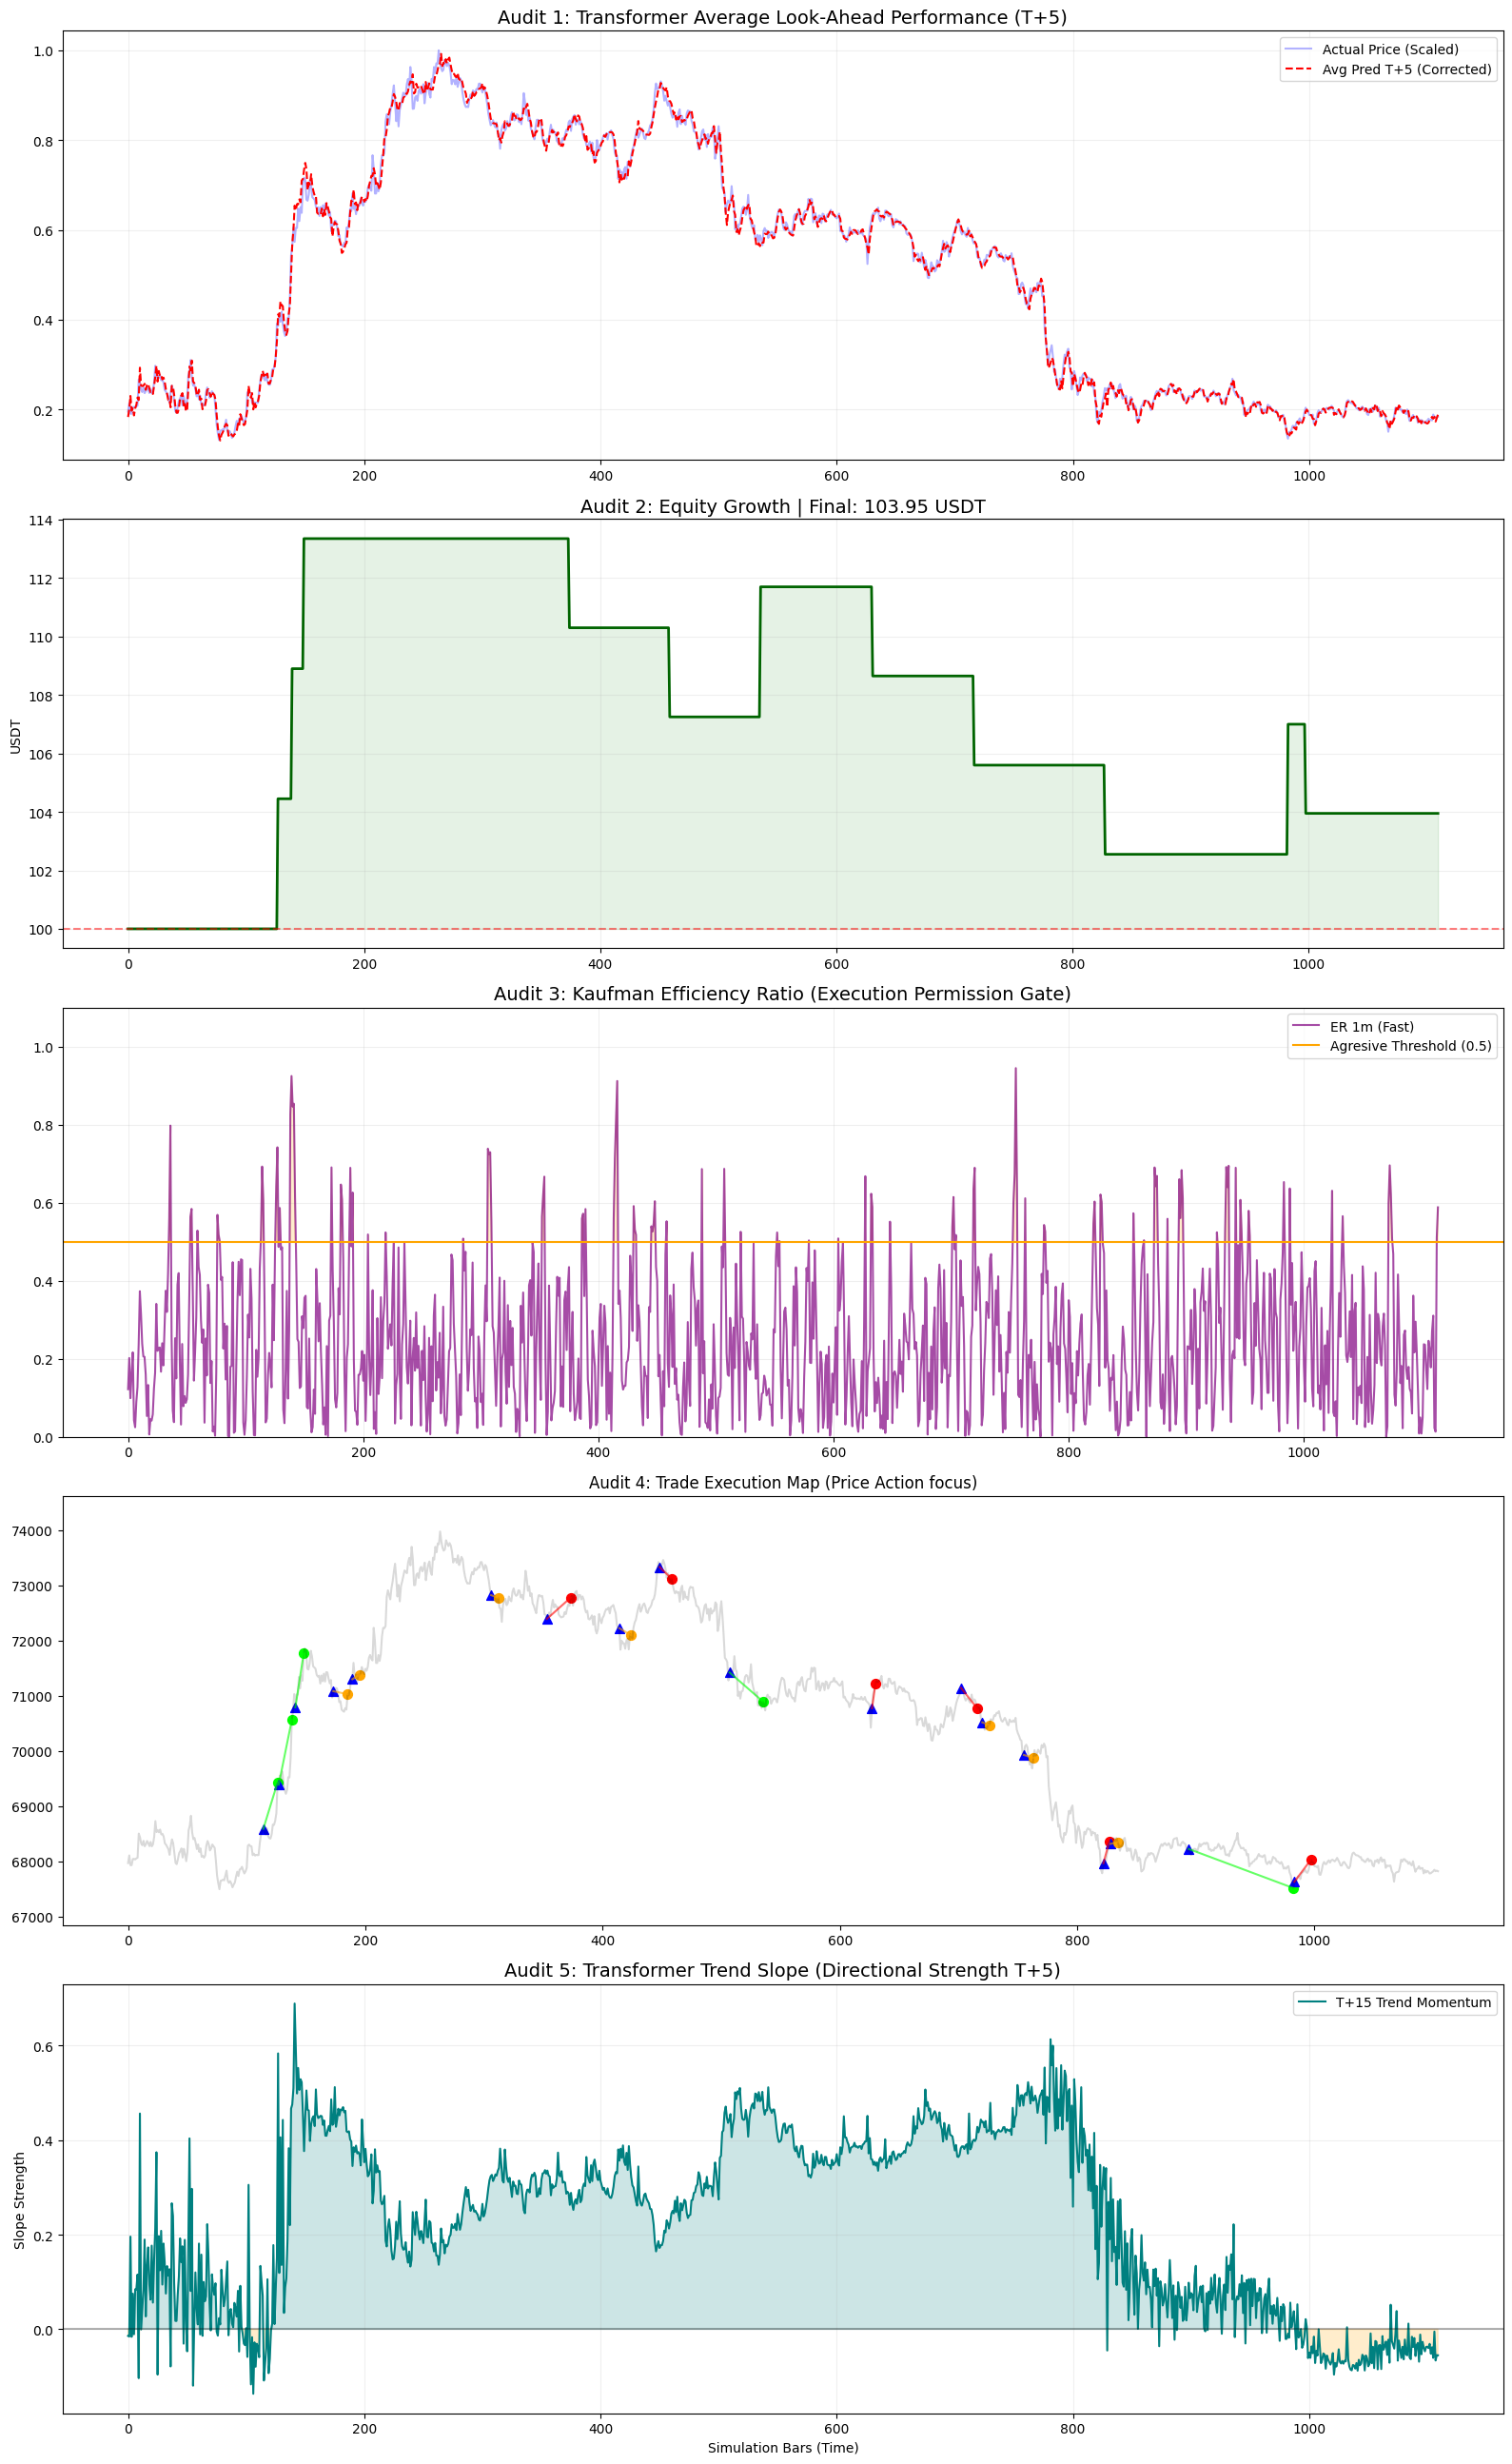

,idx_entry,idx_exit,type,entry,exit,status,net_pnl
0,194,206,LONG,68589.117188,69429.367188,TP,4.450000e+00
1,207,218,LONG,69388.921875,70561.632812,TP,4.450000e+00
2,221,228,LONG,70788.203125,71762.453125,TP,4.450000e+00
3,253,265,SHORT,71081.617188,71026.210938,BE_EXIT,-3.108624e-15
4,269,275,LONG,71297.953125,71378.195312,BE_EXIT,3.652634e-14
5,386,392,SHORT,72819.984375,72772.656250,BE_EXIT,-6.661338e-15
6,433,453,SHORT,72390.164062,72775.289062,SL,-3.050000e+00
7,494,504,SHORT,72221.929688,72094.890625,BE_EXIT,-1.032507e-14
8,528,538,LONG,73328.390625,73121.132812,SL,-3.050000e+00
9,587,615,SHORT,71419.351562,70895.507812,TP,4.450000e+00


In [3]:
# --- 6. VISUALISASI HASIL AUDIT MULTI-FACTOR (5 SUBPLOTS) ---
def to_val(x): return float(x[0]) if isinstance(x, (np.ndarray, list)) else float(x)
equity_arr = np.array([to_val(x) for x in equity_history])

# Pastikan panjang array sama untuk plotting (sinkronisasi index i)
# Karena i berhenti di len(df_sim) - 5, kita sesuaikan indexnya
plot_range = range(window_size, len(df_sim) - 5)

plt.figure(figsize=(16, 26))

# Subplot 1: Prediction Accuracy (Avg T+5 vs Actual)
plt.subplot(5, 1, 1)
plt.plot(actuals_tracking, label='Actual Price (Scaled)', color='blue', alpha=0.3)
plt.plot(preds_tracking, label='Avg Pred T+5 (Corrected)', color='red', linestyle='--',
         linewidth=1.5)
plt.title("Audit 1: Transformer Average Look-Ahead Performance (T+5)", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)

# Subplot 2: Equity Curve (Modal $100)
plt.subplot(5, 1, 2)
plt.plot(equity_arr, color='darkgreen', linewidth=2, label='Equity Balance')
plt.axhline(y=modal_awal, color='red', linestyle='--', alpha=0.5)
plt.fill_between(range(len(equity_arr)), modal_awal, equity_arr,
                 where=(equity_arr >= modal_awal), color='green', alpha=0.1)
plt.title(f"Audit 2: Equity Growth | Final: {compounding_equity:.2f} USDT", fontsize=14)
plt.ylabel("USDT")
plt.grid(True, alpha=0.2)

# Subplot 3: Kaufman ER (1m Filter - Threshold 0.4)
plt.subplot(5, 1, 3)
er_plot = df_sim['ER_1m'].values[window_size : len(df_sim)-5]
plt.plot(er_plot, color='purple', alpha=0.7, label='ER 1m (Fast)')
plt.axhline(y=0.5, color='orange', linestyle='-', label='Agresive Threshold (0.5)')
plt.fill_between(range(len(er_plot)), 0.5, er_plot, where=(er_plot > 0.5),
                 color='orange', alpha=0.2)
plt.title("Audit 3: Kaufman Efficiency Ratio (Execution Permission Gate)", fontsize=14)
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, alpha=0.2)

# Subplot 4: Trade Execution Map
plt.subplot(5, 1, 4)
price_plot = df_sim['Close'].values[window_size : len(df_sim)-15]
plt.plot(price_plot, color='black', alpha=0.15, label='BTC Price')

# --- FIX: Batasi Sumbu Y agar fokus pada area harga ---
padding = (max(price_plot) - min(price_plot)) * 0.1
plt.ylim(min(price_plot) - padding, max(price_plot) + padding)

# Filter dan Plot Trade
for t in trade_log:
    idx_entry = t['idx_entry'] - window_size
    idx_exit = t['idx_exit'] - window_size

    # Abaikan trade dengan data harga yang rusak (misal 0)
    if t['entry'] > 1000 and t['exit'] > 1000:
        c = 'lime' if t['status'] == 'TP' else 'red'
        if t['status'] == 'BE_EXIT': c = 'orange'

        plt.scatter(idx_entry, t['entry'], marker='^', color='blue', s=50)
        plt.scatter(idx_exit, t['exit'], marker='o', color=c, s=50)
        plt.plot([idx_entry, idx_exit], [t['entry'], t['exit']], color=c, alpha=0.6)

plt.title("Audit 4: Trade Execution Map (Price Action focus)")

# Subplot 5: Trend Slope Analysis (T+5 Momentum)
plt.subplot(5, 1, 5)
plt.plot(slope_tracking, color='teal', label='T+15 Trend Momentum')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.fill_between(range(len(slope_tracking)), 0, slope_tracking,
                 where=(np.array(slope_tracking) > 0), color='teal', alpha=0.2)
plt.fill_between(range(len(slope_tracking)), 0, slope_tracking,
                 where=(np.array(slope_tracking) < 0), color='orange', alpha=0.2)
plt.title("Audit 5: Transformer Trend Slope (Directional Strength T+5)", fontsize=14)
plt.xlabel("Simulation Bars (Time)")
plt.ylabel("Slope Strength")
plt.legend()
plt.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# Tampilkan tabel trade jika ada
if len(trade_log) > 0:
    display(pd.DataFrame(trade_log).tail(20))

In [4]:
# --- SIGNAL GENERATOR: ALIGNED WITH HIGH-PROB BACKTEST (LIVE READY) ---
model_loaded.eval()

# 1. KONFIGURASI SESUAI BACKTEST
look_ahead_steps_live = 10 # Mengikuti look_ahead_steps loop
er_threshold_live = 0.5    # Mengikuti er_threshold_agresif loop

# 2. GENERATE MULTI-STEP PREDICTION (T+10)
temp_window = scaled_in[-window_size:].copy()
future_preds = []

with torch.no_grad():
    for _ in range(look_ahead_steps_live):
        input_tensor = torch.FloatTensor(temp_window).unsqueeze(0).to(device)
        pred_step = model_loaded(input_tensor).item()
        future_preds.append(pred_step)

        # Auto-regressive update
        new_row = temp_window[-1].copy()
        new_row[0] = pred_step
        temp_window = np.vstack([temp_window[1:], new_row])

# 3. KALKULASI TREND & BIAS
current_bias = np.mean(errors_live[-look_ahead_steps_live:]) if errors_live else 0
actual_now_scaled = scaled_out[-1, 0]
avg_future_scaled = np.mean(future_preds) - current_bias
trend_diff = avg_future_scaled - actual_now_scaled
slope_momentum = (future_preds[-1] - actual_now_scaled)

# 4. MARKET DATA & INDICATORS (LIVE)
price_now = float(df_sim['Close'].iloc[-1])
price_ref = float(df_sim['Close'].iloc[-4]) # Referensi 3 bar sebelumnya (15 menit)
er_now = float(df_sim['ER_1m'].iloc[-1])

# Kalkulasi Z-Score Live (10 Bar)
window_prices_live = df_sim['Close'].values[-10:]
z_score_live = (price_now - np.mean(window_prices_live)) / np.std(window_prices_live)

# Kalkulasi IBS Live
h_now, l_now, c_now = float(df_sim['High'].iloc[-1]), float(df_sim['Low'].iloc[-1]), float(df_sim['Close'].iloc[-1])
ibs_live = (c_now - l_now) / (h_now - l_now) if (h_now - l_now) > 0 else 0.5

# Parameter Money Management
tp_pct = 0.024
sl_pct = 0.008
fee_cover = 0.0011

print(f"=== BYBIT SIGNAL AUDIT: {pd.Timestamp.now()} ===")
print(f"Kaufman ER (1m) : {er_now:.4f} {'[EFFICIENT]' if er_now > er_threshold_live else '[NOISY]'}")
print(f"Trend T+10 Avg  : {trend_diff:.6f} | Slope: {slope_momentum:.6f}")
print(f"Momentum Check  : Now({price_now:.2f}) vs Ref({price_ref:.2f})")
print(f"IBS Status      : {ibs_live:.2f} {'[OVERBOUGHT]' if ibs_live > 0.7 else '[OVERSOLD]' if ibs_live < 0.3 else '[NEUTRAL]'}")
print(f"Z-Score         : {z_score_live:.2f}")
print("-" * 45)

# 5. LOGIKA EKSEKUSI (SINKRON DENGAN LOOP BACKTEST)
if er_now > er_threshold_live:
    # Syarat LONG: Price Now > Price Ref DAN IBS < 0.7 (Sesuai Loop)
    if price_now > price_ref and ibs_live < 0.7:
        tp_price = price_now * (1 + tp_pct)
        sl_price = price_now * (1 - sl_pct)
        be_target = price_now * (1 + fee_cover)

        print(">>> SIGNAL: LONG (BUY) <<<")
        print(f"Entry Price  : {price_now:.2f}")
        print(f"Take Profit  : {tp_price:.2f} (+2.4%)")
        print(f"Stop Loss    : {sl_price:.2f} (-0.8%)")
        print(f"Move to BE   : {be_target:.2f} (Geser SL jika profit @ bar ke-5)")

    # Syarat SHORT: Price Now < Price Ref DAN IBS > 0.3 (Sesuai Loop)
    elif price_now < price_ref and ibs_live > 0.3:
        tp_price = price_now * (1 - tp_pct)
        sl_price = price_now * (1 + sl_pct)
        be_target = price_now * (1 - fee_cover)

        print(">>> SIGNAL: SHORT (SELL) <<<")
        print(f"Entry Price  : {price_now:.2f}")
        print(f"Take Profit  : {tp_price:.2f} (+2.4%)")
        print(f"Stop Loss    : {sl_price:.2f} (-0.8%)")
        print(f"Move to BE   : {be_target:.2f} (Geser SL jika profit @ bar ke-5)")
    else:
        print(">>> SIGNAL: WAIT (Filter Momentum/IBS Belum Terpenuhi) <<<")
else:
    print(">>> SIGNAL: NO TRADE (Pasar Terlalu Noisy / ER Low) <<<")

=== BYBIT SIGNAL AUDIT: 2026-03-07 18:47:13.167665 ===
Kaufman ER (1m) : 0.0090 [NOISY]
Trend T+10 Avg  : -0.041995 | Slope: -0.059824
Momentum Check  : Now(67603.84) vs Ref(67680.80)
IBS Status      : 0.49 [NEUTRAL]
Z-Score         : -0.81
---------------------------------------------
>>> SIGNAL: NO TRADE (Pasar Terlalu Noisy / ER Low) <<<
